# What SAE feature does each source token contribute?

SAE analog of the logit-lens cell in `cosine_seem_to_self.ipynb`. Same prompt
**`I hate this person. I think he is so`**, model `meta-llama/Llama-3.1-8B`, same cached
`FullRunResults` (no remote run).

At a chosen layer / the last position, the residual stream decomposes into one **contribution
vector per source token**. Instead of decoding each into top-5 *logit predictions* (RMSNorm +
unembedding), we decode it into its **top active SAE features** using the Llama Scope 8x/32K
residual SAEs (`llama_scope_lxr_8x`), with feature descriptions from **Neuronpedia**.

**Which SAE / gating.** `sae_lens` loads Llama Scope as a **JumpReLU** SAE (verified: 32,768
features, per-feature `threshold` tensor, *no* fixed TopK `k`). A feature fires iff its
pre-activation clears its own threshold: $f(x)=\mathrm{ReLU}(W^{enc}x+b^{enc})\cdot
\mathbb{1}[W^{enc}x+b^{enc}>\theta]$. The number of active features is input-dependent
(~tens on a real residual; **37** at layer 31 / last position here), not a fixed count. Llama Scope
was *trained* with TopK (paper arXiv 2410.20526) and released in this threshold/JumpReLU inference
form — so it is the TopK-trained Llama-3.1-8B SAE, just threshold-gated at inference.

**Why we normalize.** The threshold is calibrated for full-strength residuals, so gating is
scale-dependent and a per-source contribution is only a fraction of a real residual. We rescale
each contribution's *direction* to the real residual norm at that position
(`normalize_to=resid_norm`) — the SAE analog of the RMSNorm the logit lens applies. See
`sae_feature_lens.py`. (Verified: the `hate` contribution fires **1** feature at native magnitude
vs **43** when rescaled.)

In [1]:
%load_ext autoreload
%autoreload 1
%aimport sae_feature_lens

c:\Users\wildn\Desktop\New life\AI\Expirments\VisulaiztionInfoFlowDemo\real\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
from pathlib import Path

import torch

# Backend package (api_checks, info_flow) + this folder (sae_feature_lens) on the path.
BACKEND_SRC = Path.cwd().parents[0] / "real" / "backend" / "src"
if not BACKEND_SRC.exists():
    BACKEND_SRC = Path(
        r"c:\Users\wildn\Desktop\New life\AI\Expirments\VisulaiztionInfoFlowDemo\real\backend\src"
    )
assert BACKEND_SRC.exists(), BACKEND_SRC
sys.path.insert(0, str(BACKEND_SRC))
sys.path.insert(0, str(Path.cwd()))  # so `import sae_feature_lens` works

from api_checks.api_cache import APICache  # noqa: E402
from api_checks.position import LLMResidualPosition  # noqa: E402
from info_flow.config import Config  # noqa: E402
from sae_feature_lens import SAEFeatureLens  # noqa: E402

PROMPT = "I hate this person. I think he is so"
config = Config()
MODEL = config.info_flow_model
api_cache = APICache(hf_token=config.hf_token, cache_path=Path(config.result_cache_path))
calculator = api_cache.get_infomration_calculator(MODEL)
run = api_cache.get_full_run_results(MODEL, PROMPT)

tokens = calculator.calc_tokens(PROMPT)  # one per source position
LAST_POS = run.dimentions.prompt_len - 1
N_LAYERS = run.dimentions.layers
lens = SAEFeatureLens(device="cpu")
print("model:", MODEL, "| layers:", N_LAYERS, "| tokens:", list(enumerate(tokens)))

CACHE HIT meta-llama/Llama-3.1-8B I hate this person. I think he is so 2026-06-15 09:23:29.635364
model: meta-llama/Llama-3.1-8B | layers: 32 | tokens: [(0, '<|begin_of_text|>'), (1, 'I'), (2, ' hate'), (3, ' this'), (4, ' person'), (5, '.'), (6, ' I'), (7, ' think'), (8, ' he'), (9, ' is'), (10, ' so')]


In [3]:
# --- Parameters --------------------------------------------------------------
LAYER = N_LAYERS - 1  # any 0..N_LAYERS-1; default last layer to match the logit cell
N_SHOW = 5  # how many top SAE features to DISPLAY per source. NOT the SAE's gating:
            # the SAE is JumpReLU (32768 feats, per-feature threshold), ~tens fire per input.

pos = LLMResidualPosition(layer=LAYER, token_position=LAST_POS, is_mlp=True)
contributions = run.contributions[pos]              # (S, d_model)
resid_norm = run.precise[pos].float().norm().item()  # real residual norm at this position
assert contributions.shape[0] == len(tokens)
print(f"layer {LAYER}, last pos {LAST_POS} ({tokens[LAST_POS]!r}), "
      f"residual norm = {resid_norm:.1f}, sources = {len(tokens)}")

layer 31, last pos 10 (' so'), residual norm = 87.7, sources = 11


In [4]:
# Sanity: confirm the Neuronpedia JSON field path on one feature before trusting describe().
probe = lens.top_features(run.precise[pos].float(), LAYER, k=1)[0][0]
raw = lens.fetch_raw(LAYER, probe)
print("feature", probe, "| has 'explanations':", "explanations" in raw)
print("description:", lens.describe(LAYER, probe))

feature 15278 | has 'explanations': True
description: quantitative data and numerical references in financial contexts


In [5]:
# Decode each source's contribution -> top-N_SHOW SAE features (+ Neuronpedia descriptions).
# normalize_to=resid_norm: treat each contribution's direction as a full-strength residual.
feats_per_source = []
for i in range(len(tokens)):
    top = lens.top_features(contributions[i].float(), LAYER, k=N_SHOW, normalize_to=resid_norm)
    feats_per_source.append([(idx, act, lens.describe(LAYER, idx)) for idx, act in top])
    print(f"{i:>2}: {tokens[i].strip()!r:>16} -> "
          + ", ".join(f"{idx}({act:.1f})" for idx, act in top))

 0: '<|begin_of_text|>' -> 15278(18.8), 12810(15.2), 17502(14.4), 14751(11.8), 23605(10.9)
 1:              'I' -> 15278(19.3), 12810(15.4), 17502(13.8), 23605(11.7), 1586(8.8)
 2:           'hate' -> 12810(17.3), 1586(13.4), 15278(11.6), 4354(10.6), 14751(9.0)
 3:           'this' -> 17502(17.3), 15278(16.8), 12810(13.5), 14751(11.6), 24405(9.1)
 4:         'person' -> 15278(17.1), 12810(16.4), 17502(14.2), 23605(9.5), 4354(9.0)
 5:              '.' -> 15278(20.3), 17502(15.7), 12810(15.3), 23605(10.9), 14751(10.0)
 6:              'I' -> 15278(21.0), 12810(18.2), 17502(13.3), 23605(8.9), 4354(8.7)
 7:          'think' -> 12810(15.4), 26460(15.1), 17502(12.9), 15278(12.4), 23605(10.5)
 8:             'he' -> 15278(18.7), 17502(14.4), 12810(13.5), 23605(10.2), 14751(8.3)
 9:             'is' -> 15278(19.1), 12810(15.6), 17502(15.0), 14751(10.5), 23605(9.7)
10:             'so' -> 15278(18.5), 17502(16.0), 12810(15.3), 14751(14.4), 4354(8.1)


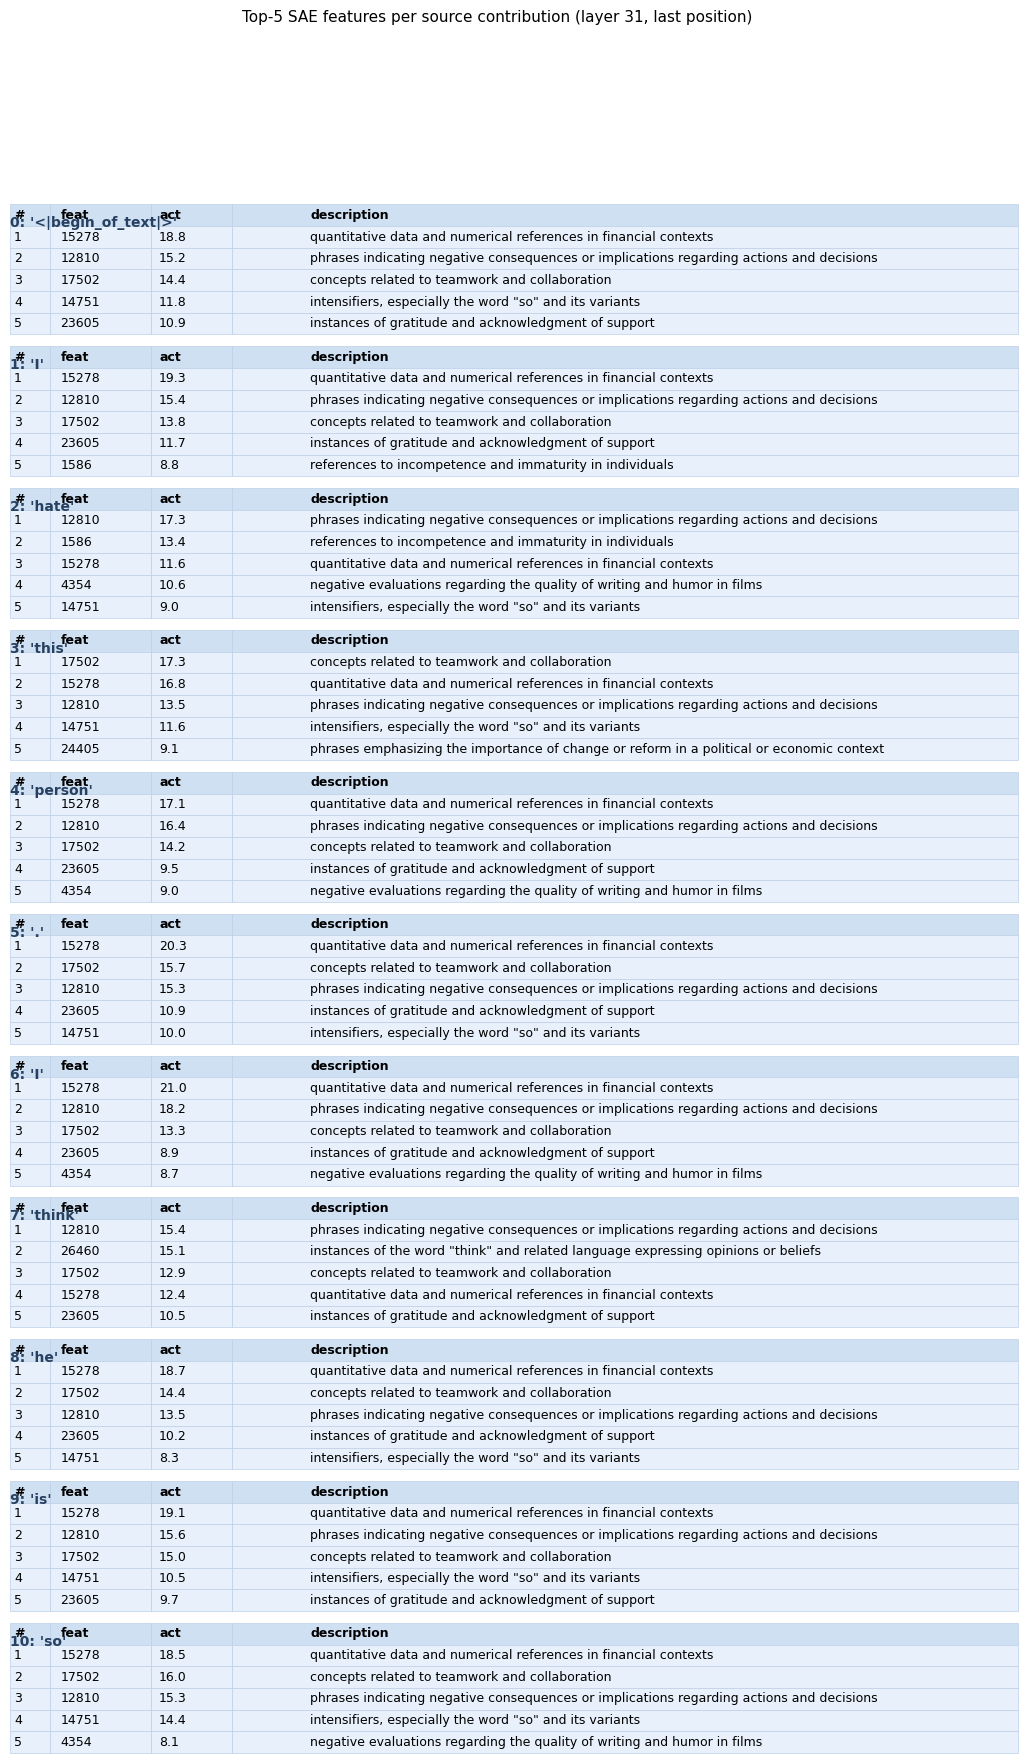

In [6]:
import matplotlib.pyplot as plt


def feature_table(tokens, feats_per_source, title, topk=5):
    """One light-blue table per source token: its top-k SAE features
    (rank, feature id, activation, Neuronpedia description). Raw view only. CLAUDE_WRITTEN"""
    col_labels = ["#", "feat", "act", "description"]
    col_widths = [0.04, 0.10, 0.08, 0.78]
    n = len(tokens)
    fig = plt.figure(figsize=(13, 1.7 * n + 0.6))
    gs = fig.add_gridspec(n, 1, hspace=1.1)

    def style(tbl, facecolor):
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1, 1.3)
        for cell in tbl.get_celld().values():
            cell.set_edgecolor("#bcd0e8")
            cell.set_linewidth(0.5)
            cell.set_facecolor(facecolor)

    for i, tok in enumerate(tokens):
        ax = fig.add_subplot(gs[i]); ax.axis("off")
        ax.set_title(f"{i}: {tok.strip()!r}", loc="left", fontsize=10,
                     fontweight="bold", color="#274060")
        rows = [col_labels]
        for r, (idx, act, desc) in enumerate(feats_per_source[i]):
            rows.append([str(r + 1), str(idx), f"{act:.1f}", desc])
        while len(rows) < topk + 1:  # pad to a fixed height
            rows.append(["", "", "", ""])
        tbl = ax.table(cellText=rows, colWidths=col_widths, cellLoc="left", loc="center")
        style(tbl, "#e8f1fb")
        for c in range(len(col_labels)):  # header row: darker + bold
            tbl[(0, c)].set_facecolor("#cfe0f3")
            tbl[(0, c)].set_text_props(fontweight="bold")
    fig.suptitle(title, fontsize=11, y=0.997)
    plt.show()


feature_table(
    tokens, feats_per_source,
    f"Top-{N_SHOW} SAE features per source contribution (layer {LAYER}, last position)",
    topk=N_SHOW,
)

## Why normalize? raw vs normalized for one token

Demonstrates the bias collapse: at its native (small) magnitude, a per-source contribution
barely clears the encoder bias threshold, so almost everything reads `0.0`. Rescaling its
direction to the real residual norm recovers a meaningful top-5.

In [7]:
demo_i = next(i for i, t in enumerate(tokens) if "hate" in t.lower())
c = contributions[demo_i].float()
print(f"token {demo_i}: {tokens[demo_i].strip()!r} | contribution norm {c.norm():.2f} "
      f"vs residual norm {resid_norm:.1f}\n")
print("raw        :", lens.top_features(c, LAYER, k=N_SHOW))
print("normalized :", lens.top_features(c, LAYER, k=N_SHOW, normalize_to=resid_norm))

token 2: 'hate' | contribution norm 11.15 vs residual norm 87.7

raw        : [(12810, 2.267343044281006), (1, 0.0), (3, 0.0), (4, 0.0), (0, 0.0)]
normalized : [(12810, 17.2514591217041), (1586, 13.440181732177734), (15278, 11.61691665649414), (4354, 10.575422286987305), (14751, 8.972082138061523)]
